In [1]:
import sys, os
# os.environ['PATH']='/projects/bdne/spandey3/tex/texlive/bin/x86_64-linux:'+ os.environ['PATH']
# os.environ['PYTHONPATH']='/projects/bdne/spandey3/tex/texlive/bin/x86_64-linux:'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION']='.9'
import jax_cosmo.background as bkgrd
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"
from jax.lib import xla_bridge
platform = xla_bridge.get_backend().platform
import jax
print(jax.local_device_count(), jax.device_count())
jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)
import jax
# Change the current working directory to the desired path
# os.chdir('/mnt/home/spandey/ceph/GODMAX/src/')

import matplotlib

import matplotlib.pyplot as pl
# set latex to false:
pl.rcParams['text.usetex'] = False
%load_ext autoreload
%autoreload 2
import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../data/") 
abs_path_src = os.path.abspath(curr_path / "../src/") 
abs_path_results = os.path.abspath(curr_path / "../results/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)
import numpyro
numpyro.set_platform("gpu")
numpyro.enable_x64()
from jax import config
config.update("jax_enable_x64", True)
import scipy.interpolate as interp
import pickle as pk
import numpy as np
import jax.numpy as jnp
import colossus 
from jax import vmap, grad, pmap
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
# Palatino
# pl.rc('font', family='DejaVu Sans')

%matplotlib inline

1 1


/mnt/home/spandey/miniconda3/envs/ili-sbi/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
from scipy.interpolate import interp1d
ks = np.geomspace(5e-2,50,15) # wavenumbers

zedges = np.array([0.4, 0.6, 0.8,1.1])
Ngals_bins = 3.33*np.array([506905, 771875, 859824])
Ngals_tot = np.sum(Ngals_bins)
Vol_Gpc3 = (14000/5840)*np.array([2.6, 4.0, 5.0])
z_cens = np.array([0.51, 0.71, 0.92])
Vol_Mpc3 = Vol_Gpc3*1e9
ngal_mpc3 = Ngals_bins/Vol_Mpc3


zedges = np.array([0.4, 0.6, 0.8,1.1])
nz_lrg_all = np.loadtxt(abs_path_data + '/pge/desi_lrg_nz.txt')
# nz_lrg_all.shape
zv, nzv = nz_lrg_all[:,0], nz_lrg_all[:,1]


nbins_lens = len(zedges) - 1
zarray_lens = np.linspace(0.001, 1.6, 100)
nz_interp = interp1d(zv, nzv, fill_value=1e-10, bounds_error=False)
nz_zarray = nz_interp(zarray_lens)
nz_lens = {}
for jb in range(nbins_lens):
    nz_jb = np.zeros_like(nz_zarray)
    indsel = np.where((zarray_lens > zedges[jb]) & (zarray_lens < zedges[jb+1]))[0]
    nz_jb[indsel] = nz_zarray[indsel]
    norm_val = np.trapz(nz_jb, zarray_lens)
    nz_jb = nz_jb/norm_val
    nz_lens[jb] = nz_jb


    



# cosmo_params_dict = {'flat': True, 'H0': 70.0, 'Om0': 0.2793, 'Ob0': 0.0463, 'sigma8': 0.821, 'ns': 0.972, 'w0':-1.0}
# cosmo_params_dict = {'flat': True, 'H0': 67.2, 'Om0': 0.31, 'Ob0': 0.049, 'sigma8': 0.81, 'ns': 0.95, 'w0':-1.0}
cosmo_params_dict = {'flat': True, 'H0': 67.2, 'Om0': 0.3136, 'Ob0': 0.0491, 'sigma8': 0.8416941, 'ns': 0.9645, 'w0':-1.0}
# cosmo_params_dict = {'flat': True, 'H0': 67.2, 'Om0': 0.29, 'Ob0': 0.049, 'sigma8': 0.783, 'ns': 0.95, 'w0':-1.0}
sim_params_dict = {}
sim_params_dict['nfw_trunc'] = True
sim_params_dict['gamma_rhogas'] = 2.0
sim_params_dict['delta_rhogas'] = 7.0
# sim_params_dict['theta_co'] = 0.01
# sim_params_dict['theta_ej'] = 1.0

sim_params_dict['theta_co_0'] = 0.01
sim_params_dict['log10_Mstar0_theta_co'] = 15.0
sim_params_dict['nu_theta_co_M'] = 0.0
sim_params_dict['nu_theta_co_z'] = 0.0

sim_params_dict['theta_ej_0'] = 1.4
sim_params_dict['log10_Mstar0_theta_ej'] = 15.0
sim_params_dict['nu_theta_ej_M'] = 0.0
sim_params_dict['nu_theta_ej_z'] = 0.0

sim_params_dict['log10_Mc0'] = 14.0
sim_params_dict['log10_Mstar0'] = 14.0
sim_params_dict['mu_beta'] = 1.1
sim_params_dict['nu_z'] = -0.2
sim_params_dict['nu_M'] = 0.0

sim_params_dict['eta_star'] = 0.3
sim_params_dict['eta_cga'] = 0.6


sim_params_dict['neg_bhse_plus_1'] = 0.833
sim_params_dict['A_starcga'] = 0.09
sim_params_dict['log10_M1_starcga'] = 11.4
sim_params_dict['epsilon_rt'] = 4.0


sim_params_dict['a_zeta'] = 0.3
sim_params_dict['n_zeta'] = 2
sim_params_dict['alpha_nt'] = 0.18
sim_params_dict['beta_nt'] = 0.5
sim_params_dict['n_nt'] = 0.3
sim_params_dict['cosmo'] = cosmo_params_dict

hod_params_dict = {}
hod_params_dict['logMmin'] = 12.88
hod_params_dict['sigma_logM'] = 0.2
hod_params_dict['logM0'] = 12.88
hod_params_dict['logM1'] = 14.0
hod_params_dict['alpha'] = 1.3
sim_params_dict['hod_params'] = hod_params_dict
sim_params_dict['hod_type'] = 'Zheng05'


halo_params_dict = {}
halo_params_dict['rmin'], halo_params_dict['rmax'], halo_params_dict['nr'] = 5e-3, 12, 48
halo_params_dict['zmin'], halo_params_dict['zmax'], halo_params_dict['nz'] = 0.01, 1.6, 22
halo_params_dict['lg10_Mmin'], halo_params_dict['lg10_Mmax'], halo_params_dict['nM'] = 11.0, 16.0, 24
# halo_params_dict['cmin'], halo_params_dict['cmax'], halo_params_dict['nc'] = 2, 9, 16

lmin = 10.0
lmax = 11000.0
fac = 1
dl_log_array = 0.23025851 / fac
# dl_log_array = 0.1
l_array_all = np.exp(np.arange(np.log(lmin), np.log(lmax), dl_log_array))
dl_array = l_array_all[1:] - l_array_all[:-1]
l_array_survey = (l_array_all[1:] + l_array_all[:-1]) / 2.
halo_params_dict['ell_array'] = jnp.array(l_array_survey)
halo_params_dict['nell'] = len(l_array_survey)
halo_params_dict['ellmin'] = l_array_survey[0]
halo_params_dict['ellmax'] = l_array_survey[-1]
# halo_params_dict['ellmin'], halo_params_dict['ellmax'], halo_params_dict['nell'] = 8, 2**14, 32
# try:
halo_params_dict['sig_logc_z_array'] = np.ones(halo_params_dict['nz']) * 0.05
halo_params_dict['mdef'] = '200c'
halo_params_dict['hmf_model'] = 'T10'
# halo_params_dict['conc_model'] = 'Diemer15'
halo_params_dict['conc_model'] = 'Duffy08'
halo_params_dict['do_corr_2h_mm'] = True

# halo_params_dict['do_corr_2h_mm'] = False
analysis_dict = {}

from astropy.io import fits
df = fits.open(os.path.abspath(abs_path_data + '/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits'))
# df = fits.open('data/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits') 
z_array = df['nz_source'].data['Z_MID']
nz_info_dict = {}
nz_info_dict['z_array_source'] = z_array
nz_info_dict['nbins'] = 4
nz_info_dict['nz0'] = np.maximum(df['nz_source'].data['BIN1'], 1e-4)
nz_info_dict['nz1'] = np.maximum(df['nz_source'].data['BIN2'], 1e-4)
nz_info_dict['nz2'] = np.maximum(df['nz_source'].data['BIN3'], 1e-4)
nz_info_dict['nz3'] = np.maximum(df['nz_source'].data['BIN4'], 1e-4)
analysis_dict['nz_source_info_dict'] = nz_info_dict

nz_info_dict = {}
nz_info_dict['z_array_lens'] = zarray_lens
nz_info_dict['nbins_lens'] = 3
nz_info_dict['nz0'] = np.maximum(nz_lens[0], 1e-4)
nz_info_dict['nz1'] = np.maximum(nz_lens[1], 1e-4)
nz_info_dict['nz2'] = np.maximum(nz_lens[2], 1e-4)
analysis_dict['nz_lens_info_dict'] = nz_info_dict

analysis_dict['zmin_pk'] = 0.01
analysis_dict['zmax_pk'] = 1.6
analysis_dict['nz_pk'] = 128

analysis_dict['do_ky'] = True
analysis_dict['do_kk'] = True
analysis_dict['do_gy'] = True
analysis_dict['do_gk'] = True
analysis_dict['do_gg'] = True
analysis_dict['do_ge'] = True

analysis_dict['fsky_yy'] = 0.4
analysis_dict['fsky_ky'] = 18000/41253
analysis_dict['fsky_kk'] = 18000/41253
analysis_dict['fsky_yg'] = (14000/41253)
analysis_dict['fsky_kg'] = 0.1
analysis_dict['fsky_gg'] = (14000/41253)

analysis_dict['fac_ell_hres'] = fac

# df_data = fits.open('/mnt/home/spandey/ceph/GODMAX/data/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits')
# df_data = fits.open('/mnt/home/spandey/ceph/GODMAX/data/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits')
theta_data = df['xip'].data['ANG'][0:20]

# analysis_dict['ellmin_transf'], analysis_dict['ellmax_transf'], analysis_dict['nell_transf'] = 8, 2**15, 16384
analysis_dict['angles_data_array'] = jnp.array(theta_data)
analysis_dict['beam_fwhm_arcmin'] = 1.6
analysis_dict['want_like_diff'] = True
analysis_dict['calc_nfw_only'] = False
analysis_dict['conc_dep_model'] = False


analysis_dict['get_cov'] = True
analysis_dict['stats_for_cov'] = ['ky', 'kk', 'gy', 'gg', 'gk']
analysis_dict['analysis_coords'] = 'fourier'
# l_array_survey = np.logspace(np.log10(lmin), np.log10(lmax), int((lmax-lmin)/dl_log_array)+1)
analysis_dict['l_array_survey'] = jnp.array(l_array_survey)

analysis_dict['k_array_survey'] = jnp.array(ks)

analysis_dict['dl_array_survey'] = jnp.array(dl_array)
# analysis_dict['yy_total_ell_fname'] = '/Users/shivam/Downloads/ACT_Cls/Cls_ilc_SZ_deproj_cib_cibdBeta_1.7_10.7_yy_apod10arcmin_21Mar24.txt'
# analysis_dict['yy_total_ell_fname'] = '/Users/shivam/Downloads/ACT_Cls/Cls_ilc_SZ_yy_apod10arcmin_21Mar24.txt'
analysis_dict['yy_total_ell_fname'] = os.path.abspath(abs_path_data + '/DESxACT/ACT_Cls/Cls_ilc_SZ_yy_apod10arcmin_21Mar24.txt')
# analysis_dict['sigma_epsilon_SN_bins'] = [0.2724, 0.2724, 0.2724, 0.2724]
# analysis_dict['neff_arcmin2_SN_bins'] = [1.7971, 1.5521, 1.5967, 1.0979]

analysis_dict['sigma_epsilon_SN_bins'] = [0.243, 0.262, 0.259, 0.301]
analysis_dict['neff_arcmin2_SN_bins'] = [1.476, 1.479, 1.484, 1.461]

analysis_dict['nbar_lens_bins'] = Ngals_bins/(analysis_dict['fsky_gg']*41253*(60**2))

other_params_dict = {}
other_params_dict['A_IA'] = 0.0
other_params_dict['eta_IA'] = 0.0
other_params_dict['z0_IA'] = 0.62
other_params_dict['C1_rhocrit'] = 0.0134
other_params_dict['Delta_z_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])
other_params_dict['mult_shear_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])






In [3]:
from get_BCMP_profile import BCM_18_wP
BCMP_test = BCM_18_wP(sim_params_dict, halo_params_dict)



In [4]:
from setup_power_spectra import setup_power_BCMP
set_power_BCMP_test = setup_power_BCMP(sim_params_dict, halo_params_dict, analysis_dict, verbose_time=False)



In [10]:
from get_power_spectra import get_power_BCMP

get_power_test = get_power_BCMP(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)



/tmp/ipykernel_324712/4015807109.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  pl.legend(fontsize=16)


(0.1, 10)

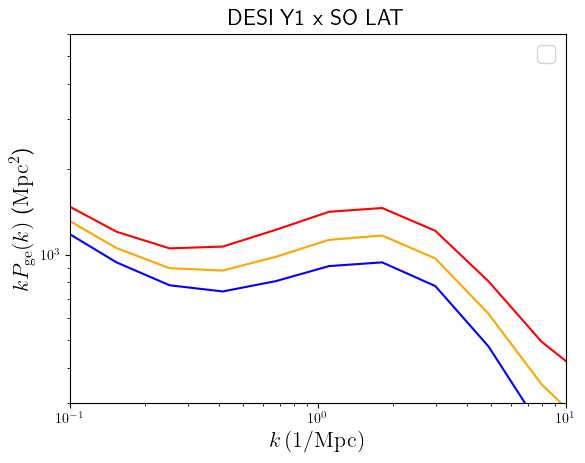

In [16]:
pl.rc('text', usetex=True)
h = 0.7
# make a three panel plot, plotting all the theta_ej curves for for gty_out_thetaej[:,3,:], xip_out_thetaej[:,3,3,:], xim_out_thetaej[:,3,3,:]
# draw theta_ej curves from a colormap
from matplotlib import cm, colorbar
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
# cmap = cm.get_cmap('coolwarm')  # or any other colormap you like
# create a normalize object the scales the input Mc0 value to the range [0,1]
# norm = Normalize(vmin=(theta_ej_array).min(), vmax=(theta_ej_array).max())
# analysis_dict_vary['angles_data_array'] = jnp.logspace(np.log10(0.5), np.log10(100), fac_th * len(theta_data))
# dsfac = 2
# indz = np.argmin(np.abs(zs - z_cens[0]))
# pl.errorbar(0.95*ks[::dsfac],(ks*Pge[indz])[::dsfac], (ks*Pge_err_z0)[::dsfac],label=r'$\langle z \rangle$=0.51', color='red', ls='', marker='o')

# indz = np.argmin(np.abs(zs - z_cens[1]))
# pl.errorbar(ks[::dsfac],(ks*Pge[indz])[::dsfac], (ks*Pge_err_z1)[::dsfac],label=r'$\langle z \rangle$=0.71', color='orange', ls='', marker='o')

# indz = np.argmin(np.abs(zs - z_cens[2]))
# pl.errorbar(1.05*ks[::dsfac],(ks*Pge[indz])[::dsfac], (ks*Pge_err_z2)[::dsfac],label=r'$\langle z \rangle$=0.92', color='blue', ls='', marker='o')

fac = get_power_test.k_array_survey
pl.plot(get_power_test.k_array_survey*h, fac*get_power_test.Pge_tot_mat[0,:]*(1/h**2), color='red')
pl.plot(get_power_test.k_array_survey*h, fac*get_power_test.Pge_tot_mat[1,:]*(1/h**2), color='orange')
pl.plot(get_power_test.k_array_survey*h, fac*get_power_test.Pge_tot_mat[2,:]*(1/h**2), color='blue')

pl.title('DESI Y1 x SO LAT', fontsize=16)
pl.ylim(3e2, 6e3)
pl.legend(fontsize=16)
pl.xscale('log')
pl.yscale('log')
pl.xlabel(r'$k \,  (1/{\rm Mpc})$', fontsize=16)
pl.ylabel(r'$kP_{\rm ge}(k)$ (${\rm Mpc}^2$)', fontsize=16)
pl.xlim(0.1, 10)


In [ ]:
jnp.log10(self.get_Mstar_Mh(jz, jM))

In [77]:
Mth, nbar, nbarinp, lg10Mth_array, Ncen_mat, Nsat_mat, M_array = BCMP_test.get_Mthresh(4)


In [78]:
# Ncen_mat
# lg10Mth_array
Mth
# jnp.interp(0.0, nbarinp-nbar, lg10Mth_array)


Array(10.96195643, dtype=float64)

In [79]:
nbar-nbarinp


Array([ 2.25629587e-02,  2.13681497e-02,  2.02232778e-02,  1.90585433e-02,
        1.77489375e-02,  1.61382422e-02,  1.41273570e-02,  1.17659076e-02,
        9.24961114e-03,  6.82134656e-03,  4.67315136e-03,  2.91344882e-03,
        1.57900169e-03,  6.51979651e-04,  7.19354772e-05, -2.48941285e-04,
       -4.03435506e-04, -4.67599100e-04, -4.90549640e-04, -4.97625649e-04,
       -4.99495249e-04, -4.99911260e-04, -4.99987356e-04, -4.99998560e-04,
       -4.99999870e-04, -4.99999991e-04, -4.99999999e-04, -5.00000000e-04,
       -5.00000000e-04, -5.00000000e-04], dtype=float64)

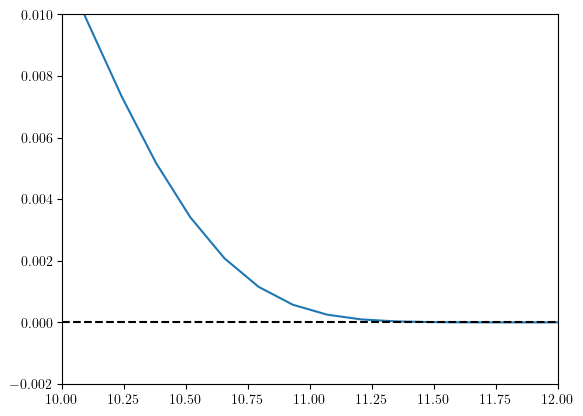

In [81]:
pl.figure()
pl.plot(lg10Mth_array, nbar)
# pl.axhline(nbarinp, color='k', ls='--')
pl.ylim(-0.002, 0.01)
pl.xlim(10,12)
pl.axhline(0, color='k', ls='--')

In [82]:
BCMP_test.get_Mstar_Mh(0,1)



Array(1.10000266e+10, dtype=float64)